### Load libraries

In [1]:
from pybaseball import statcast

import pandas as pd
import numpy as np
import polars as pl

import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error

import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

import requests

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# collect Statcast data
# documentation: https://baseballsavant.mlb.com/csv-docs
start_date = '2020-03-01'
end_date = '2025-10-31'

raw_data = statcast(start_date, end_date)
#raw_data = pd.read_csv('df_2020_2024.csv')
print(raw_data.shape)

This is a large query, it may take a moment to complete


  0%|                                                                                         | 0/1312 [00:00<?, ?it/s]

Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates
Skipping offseason dates


100%|██████████████████████████████████████████████████████████████████████████████| 1312/1312 [08:02<00:00,  2.72it/s]


(4126175, 118)


In [3]:
df = raw_data.copy().reset_index(drop=True)
# re-format names to readable format
split_names = df["player_name"].fillna("").str.split(",", n=1)
df["PlayerName"] = np.where(
    split_names.str.len() == 2,
    split_names.str[1].str.strip() + " " + split_names.str[0].str.strip(),
    df["player_name"]
)

In [4]:
## Define a dictionary to group outcomes together for expected run values
des_dict = {'ball':'ball',
'hit_into_play':'hit_into_play',
'called_strike':'called_strike',
'foul':'foul',
'swinging_strike':'swinging_strike',
'blocked_ball':'ball',
'swinging_strike_blocked':'swinging_strike',
'foul_tip':'swinging_strike',
'foul_bunt':'foul',
'hit_by_pitch':'hit_by_pitch',
'pitchout':'ball',
'missed_bunt':'swinging_strike',
'bunt_foul_tip':'swinging_strike',
'foul_pitchout':'foul',}

## Define a dictionary to group events together for expected run values
ev_dict = {'game_advisory':np.nan,
 'single':'single',
 'walk':'walk',
 np.nan:np.nan,
 'strikeout':'strikeout',
 'field_out':'field_out',
 'force_out':'field_out',
 'double':'double',
 'hit_by_pitch':'hit_by_pitch',
 'home_run':'home_run',
 'grounded_into_double_play':'field_out',
 'fielders_choice_out':'field_out',
 'fielders_choice':'field_out',
 'field_error':np.nan,
 'double_play':'field_out',
 'sac_fly':'field_out',
 'strikeout_double_play':np.nan,
 'triple':'triple',
 'caught_stealing_2b':np.nan,
 'sac_bunt':'field_out',
 'catcher_interf':np.nan,
 'caught_stealing_3b':np.nan,
 'sac_fly_double_play':'field_out',
 'triple_play':'field_out',
 'other_out':'field_out',
 'pickoff_3b':np.nan,
 'caught_stealing_home':np.nan,
 'pickoff_1b':np.nan,
 'pickoff_2b':np.nan,
 'wild_pitch':'wild_pitch',
 'stolen_base_2b':np.nan,
 'pickoff_caught_stealing_3b':np.nan,
 'pickoff_caught_stealing_2b':np.nan,
 'sac_bunt_double_play':np.nan,
 'passed_ball':np.nan,
 'pickoff_caught_stealing_home':np.nan,}

In [5]:
## Define lists which contain Swing Outcomes
swing_in = ['foul_bunt','foul','hit_into_play','swinging_strike', 'foul_tip', 'swinging_strike_blocked','missed_bunt','bunt_foul_tip']

In [6]:
## Define a function which applies relevant transformations
## Code derived from Thomas Nestico

def clean_for_xrv(df, VAL_YEAR):
    df = df[(df.balls != 4) & (df.strikes != 3)].copy()

    df["des_new"] = df["description"].map(des_dict)
    df["des_new"] = np.where((df["des_new"] == "ball") & (df["balls"] == 3), "walk", df["des_new"])
    df["des_new"] = np.where(
        (df["des_new"].isin(["called_strike", "swinging_strike"])) & (df["strikes"] == 2),
        "strikeout",
        df["des_new"],
    )
    df["ev_new"] = df.loc[df["des_new"] == "hit_into_play", "events"].map(ev_dict)
    df.loc[df["des_new"] == "hit_into_play", "des_new"] = df.loc[df["des_new"] == "hit_into_play", "ev_new"]
    df = df.dropna(subset=["des_new"])

    # IMPORTANT: make mask positional (avoids index alignment bugs)
    train_mask = (df["game_year"].to_numpy() < VAL_YEAR)

    des_values = (
        df.loc[train_mask]
          .groupby(["des_new", "strikes", "balls"])["delta_run_exp"]
          .mean()
          .reset_index(name="delta_run_exp_mean")
    )

    df = df.merge(des_values, on=["des_new", "strikes", "balls"], how="left")

    global_mean = df.loc[train_mask, "delta_run_exp"].mean()
    df["delta_run_exp_mean"] = df["delta_run_exp_mean"].fillna(global_mean)

    return df.dropna(subset=["pitch_type"])

In [7]:
def add_primary_pitch_deltas(
    df,
    primary_choices=("FF", "SI", "FC"),
    *,
    pitcher_col="pitcher",
    year_col="game_year",
    pitch_type_col="pitch_type",
    speed_col="release_speed",
    pfx_x_col="pfx_x",
    pfx_z_col="pfx_z",
):
    """
    Adds primary pitch baseline per pitcher-season and deltas vs that baseline.

    Primary pitch definition:
      - among `primary_choices`, pick the most-used pitch type for a given pitcher-season
      - tiebreaker: higher avg speed

    Fallback if pitcher-season throws none of `primary_choices`:
      - use fastest pitch (by avg speed) for that pitcher-season

    Returns a pandas DataFrame with:
      - avg_primary_speed, avg_primary_pfx_x, avg_primary_pfx_z
      - primary_delta_release_speed, primary_delta_pfx_x, primary_delta_pfx_z
    """

    pdf = df.copy()
    pl_df = pl.from_pandas(pdf)

    group_keys = [pitcher_col, year_col, pitch_type_col]

    # aggregate pitch-type means + counts per pitcher-season
    agg = (
        pl_df.group_by(group_keys)
        .agg(
            pl.len().alias("pt_count"),
            pl.col(speed_col).mean().alias("pt_avg_speed"),
            pl.col(pfx_z_col).mean().alias("pt_avg_pfx_z"),
            pl.col(pfx_x_col).mean().alias("pt_avg_pfx_x"),
        )
    )

    # candidate primary among chosen pitch types
    primary_candidates = (
        agg.filter(pl.col(pitch_type_col).is_in(list(primary_choices)))
        .sort(
            by=[pitcher_col, year_col, "pt_count", "pt_avg_speed"],
            descending=[False, False, True, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("avg_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("avg_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("avg_primary_pfx_x"),
        )
    )

    # fallback: fastest pitch type for that pitcher-season (if no primary_choices)
    fastest_fallback = (
        agg.sort(
            by=[pitcher_col, year_col, "pt_avg_speed"],
            descending=[False, False, True],
        )
        .unique(subset=[pitcher_col, year_col], keep="first")
        .select(
            pitcher_col,
            year_col,
            pl.col("pt_avg_speed").alias("fb_primary_speed"),
            pl.col("pt_avg_pfx_z").alias("fb_primary_pfx_z"),
            pl.col("pt_avg_pfx_x").alias("fb_primary_pfx_x"),
        )
    )

    # join both baselines to every pitch row
    pl_df = (
        pl_df.join(primary_candidates, on=[pitcher_col, year_col], how="left")
             .join(fastest_fallback, on=[pitcher_col, year_col], how="left")
             .with_columns(
                 pl.when(pl.col("avg_primary_speed").is_null())
                   .then(pl.col("fb_primary_speed"))
                   .otherwise(pl.col("avg_primary_speed"))
                   .alias("avg_primary_speed"),
                 pl.when(pl.col("avg_primary_pfx_z").is_null())
                   .then(pl.col("fb_primary_pfx_z"))
                   .otherwise(pl.col("avg_primary_pfx_z"))
                   .alias("avg_primary_pfx_z"),
                 pl.when(pl.col("avg_primary_pfx_x").is_null())
                   .then(pl.col("fb_primary_pfx_x"))
                   .otherwise(pl.col("avg_primary_pfx_x"))
                   .alias("avg_primary_pfx_x"),
             )
             .drop(["fb_primary_speed", "fb_primary_pfx_z", "fb_primary_pfx_x"])
    )

    # deltas vs baseline
    pl_df = pl_df.with_columns(
        (pl.col(speed_col) - pl.col("avg_primary_speed")).alias("primary_delta_release_speed"),
        (pl.col(pfx_z_col) - pl.col("avg_primary_pfx_z")).alias("primary_delta_pfx_z"),
        (pl.col(pfx_x_col) - pl.col("avg_primary_pfx_x")).alias("primary_delta_pfx_x"),
    )

    pl_df = pl_df.with_columns(pl.col(year_col).cast(pl.Int64))

    return pl_df.to_pandas()

In [8]:
def clean_data(df, VAL_YEAR):
    
    # filters
    df = df[df.game_type == 'R'].copy() # regular season games
    df = df[df.release_extension > 0] # eliminate because we calculate log_extension below
    
    # drop rows with nan
    must_have_cols = ['p_throws', 'pfx_x', 'pfx_z', 'release_speed', 'spin_axis', 'release_spin_rate',
                      'release_extension', 'release_pos_x', 'release_pos_z', 'arm_angle']
    df = df.dropna(subset=must_have_cols)

    # drop rows with unidentifiable pitch
    df = df[df.pitch_name != 'Other']
    
    # eliminate bunts
    bunt_plays = ['bunt_foul_tip', 'foul_bunt', 'missed_bunt']
    df = df[~df.description.isin(bunt_plays)]

    # eliminate the data points with clearly wrong release_extension; by inspection, there's at least one from Jameson Taillon
    df = df[df.release_extension <= 10]

    # rename columns
    df = df.rename(columns={'stand': 'batter_handedness'})

    # drop deprecated columns
    deprecated_columns = [col for col in df.columns if 'deprecated' in col]
    df = df.drop(columns = deprecated_columns)

    # drop rows where pitch_type is too infrequent
    vc = df['pitch_type'].value_counts()
    included_pitches = vc[vc >= 5000]
    df = df[df.pitch_type.isin(included_pitches.index)]

    # handedness sign: L = +1, R = -1
    h = np.where(df['p_throws'] == 'L', 1.0, -1.0)

    # convert movement to inches and normalize horizontal direction
    df['pfx_x'] = df['pfx_x'] * 12.0 * h
    df['pfx_z'] = df['pfx_z'] * 12.0
    
    # create spin_efficiency feature
    eps = 1e-9
    train_mask = df['game_year'] < VAL_YEAR # ensure no temporal leakage

    df['total_movement'] = np.sqrt(df['pfx_x']**2 + df['pfx_z']**2)
    df['spin_efficiency_raw'] = df['total_movement'] * df['release_speed'] / (df['release_spin_rate'] + eps)
    q95 = df.loc[train_mask].groupby('pitch_type')['spin_efficiency_raw'].quantile(0.95)
    df['spin_eff_q95'] = df['pitch_type'].map(q95)
    df['spin_eff_q95'] = df['spin_eff_q95'].fillna(df.loc[train_mask, 'spin_efficiency_raw'].quantile(0.95))
    
    df['spin_efficiency'] = (df['spin_efficiency_raw'] / (df['spin_eff_q95'] + eps)).clip(0, 1.2)
    df = df.drop(columns=['spin_eff_q95'])

    # mirror release_pos_x
    df['release_pos_x'] = df['release_pos_x'] * h

    # normalize spin axis for handedness and mirror righties into lefty frame
    df['spin_axis_norm'] = np.where(df['p_throws'] == 'L', df['spin_axis'], (360.0 - df['spin_axis']))

    # spin axis vectors from the normalized axis
    df['spin_axis_norm'] = pd.to_numeric(df['spin_axis_norm'], errors='coerce')
    df = df.dropna(subset=['spin_axis_norm'])
    df['spin_axis_rad'] = np.deg2rad(df['spin_axis_norm'])
    df['spin_axis_x'] = np.cos(df['spin_axis_rad'])
    df['spin_axis_y'] = np.sin(df['spin_axis_rad'])
    
    # create log_extension
    df['log_extension'] = np.log(df['release_extension'])
    
    # filter pitcher-year pitch types
    counts = df.groupby(['pitcher', 'game_year', 'pitch_type']).size().rename('count')
    totals = df.groupby(['pitcher', 'game_year']).size().rename('total')

    pitch_frequencies = counts.to_frame().join(totals, on=['pitcher', 'game_year'])
    pitch_frequencies['usage'] = pitch_frequencies['count'] / pitch_frequencies['total']
    pitch_frequencies = pitch_frequencies.reset_index()

    # keep pitch types that are non-trivial for that pitcher in that season
    pitch_frequencies = pitch_frequencies[(pitch_frequencies['count'] >= 10) & (pitch_frequencies['usage'] > 0.01)]

    df = df.merge(
        pitch_frequencies[['pitcher', 'game_year', 'pitch_type']],
        on=['pitcher', 'game_year', 'pitch_type'],
        how='inner'
    )

    return df, pitch_frequencies

In [9]:
year_col = "game_year"
pitch_type_col = "pitch_type"
TARGET = "delta_run_exp_mean"

ALL_YEARS = sorted(df[year_col].dropna().astype(int).unique())
if len(ALL_YEARS) < 3:
    raise ValueError(f"Need >=3 distinct years for train/tune/report. Found: {ALL_YEARS}")

REPORT_YEAR = int(ALL_YEARS[-1])
VAL_YEAR    = int(ALL_YEARS[-2])          # tune / early-stop year
TRAIN_YEARS = [int(y) for y in ALL_YEARS[:-2]]

print(f"Train years: {TRAIN_YEARS}")
print(f"Tune year:   {VAL_YEAR}")
print(f"Report year: {REPORT_YEAR}")

Train years: [2020, 2021, 2022, 2023]
Tune year:   2024
Report year: 2025


In [10]:
df = clean_for_xrv(df, VAL_YEAR)

In [11]:
# Clean + engineer features
primary_choices = ['FF', 'SI', 'FC']
df, pitch_frequencies = clean_data(df, VAL_YEAR)
df = add_primary_pitch_deltas(df, primary_choices=primary_choices)

In [12]:
numeric_features = [
    'pfx_x','pfx_z','release_speed','release_spin_rate','release_extension',
    'release_pos_x','release_pos_z', 'spin_axis_x', 'spin_axis_y', 'spin_efficiency',
    'primary_delta_release_speed','primary_delta_pfx_x','primary_delta_pfx_z'
]

categorical_features = [pitch_type_col]

model_features = numeric_features + categorical_features

ID_COLS = ["pitcher", "PlayerName"]
df_current = df[ID_COLS + [year_col] + model_features + [TARGET]].copy()

In [13]:
def tune_refit_predict(
    df_all,
    *,
    year_col="game_year",
    pitch_type_col="pitch_type",
    target_col=TARGET,
    model_features=model_features,
    tune_year=2024,
    report_year=2025,
    train_years=(2020, 2021, 2022, 2023),
    n_trials=50,
):

    N_ESTIMATORS_MAX = 5000
    early_stopping_rounds = 100
    seed = 162

    # 1) Tune on tune_year
    df_train = df_all[df_all[year_col].isin(train_years)].copy()
    df_tune  = df_all[df_all[year_col] == tune_year].copy()

    X_train = df_train[model_features].copy()
    y_train = df_train[target_col]
    X_tune  = df_tune[model_features].copy()
    y_tune  = df_tune[target_col]

    X_train[pitch_type_col] = X_train[pitch_type_col].astype("category")
    X_tune[pitch_type_col]  = X_tune[pitch_type_col].astype("category")

    def objective(trial):
        params = {
            "random_state": seed,
            "metric": "rmse",
            "n_estimators": N_ESTIMATORS_MAX,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 200, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "force_row_wise": True,
            "verbosity": -1,
        }

        model = LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_tune, y_tune)],
            eval_metric="rmse",
            categorical_feature=[pitch_type_col],
            callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
        )
        preds = model.predict(X_tune)
        return mean_squared_error(y_tune, preds, squared=False)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # capture best params
    best_params = study.best_params.copy()
    best_params.update({
        "random_state": seed,
        "metric": "rmse",
        "force_row_wise": True,
        "verbosity": -1,
    })

    # fit a probe model once more to get best_iteration_
    probe_params = best_params.copy()
    probe_params["n_estimators"] = N_ESTIMATORS_MAX

    probe = LGBMRegressor(**probe_params)
    probe.fit(
        X_train, y_train,
        eval_set=[(X_tune, y_tune)],
        eval_metric="rmse",
        categorical_feature=[pitch_type_col],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)],
    )
    best_n_estimators = int(getattr(probe, "best_iteration_", None) or N_ESTIMATORS_MAX)
    best_params["n_estimators"] = best_n_estimators

    # 2) Refit on (train_years + tune_year), params fixed
    refit_years = list(train_years) + [tune_year]
    df_refit = df_all[df_all[year_col].isin(refit_years)].copy()
    X_refit  = df_refit[model_features].copy()
    y_refit  = df_refit[target_col]

    X_refit[pitch_type_col] = X_refit[pitch_type_col].astype("category")

    final_model = LGBMRegressor(**best_params)
    final_model.fit(
        X_refit, y_refit,
        categorical_feature=[pitch_type_col],
    )

    # 3) Predict/report on report_year
    df_report = df_all[df_all[year_col] == report_year].copy()
    X_report  = df_report[model_features].copy()
    X_report[pitch_type_col] = X_report[pitch_type_col].astype("category")

    df_report["pred_target_oos"] = final_model.predict(X_report)

    return final_model, study, df_report, best_n_estimators

In [14]:
model, study, df_report_pred, best_n = tune_refit_predict(
    df_current,
    tune_year=VAL_YEAR,
    report_year=REPORT_YEAR,
    train_years=tuple(TRAIN_YEARS),
    n_trials=50,
)

print("\nBest tune RMSE:", study.best_value)
print("Best params:", study.best_params)
print("Chosen n_estimators:", best_n)

[I 2026-02-05 16:06:20,204] A new study created in memory with name: no-name-e5a5f48a-f89a-4349-902c-c3dfe89a0c7e
[I 2026-02-05 16:06:42,819] Trial 0 finished with value: 0.21637216911329582 and parameters: {'learning_rate': 0.04478935878612179, 'max_depth': 9, 'num_leaves': 50, 'min_child_samples': 77, 'subsample': 0.9008155484197562, 'colsample_bytree': 0.8691640164089374, 'reg_alpha': 0.010923048235630301, 'reg_lambda': 0.07083969950127693}. Best is trial 0 with value: 0.21637216911329582.
[I 2026-02-05 16:07:21,118] Trial 1 finished with value: 0.21637415484114333 and parameters: {'learning_rate': 0.010257583163191432, 'max_depth': 10, 'num_leaves': 238, 'min_child_samples': 24, 'subsample': 0.5964184400379104, 'colsample_bytree': 0.8932361070144161, 'reg_alpha': 0.05508200164464109, 'reg_lambda': 0.03958704548328935}. Best is trial 0 with value: 0.21637216911329582.
[I 2026-02-05 16:07:44,313] Trial 2 finished with value: 0.21637828735195147 and parameters: {'learning_rate': 0.084

[I 2026-02-05 16:16:06,831] Trial 21 finished with value: 0.21637110228825035 and parameters: {'learning_rate': 0.02450378780745926, 'max_depth': 9, 'num_leaves': 251, 'min_child_samples': 19, 'subsample': 0.597535520519563, 'colsample_bytree': 0.8294629062316412, 'reg_alpha': 5.211729408204148, 'reg_lambda': 1.229591264815195}. Best is trial 18 with value: 0.21636567285088676.
[I 2026-02-05 16:16:16,248] Trial 22 finished with value: 0.21637218755378798 and parameters: {'learning_rate': 0.03628571938496116, 'max_depth': 9, 'num_leaves': 202, 'min_child_samples': 10, 'subsample': 0.6300795510775218, 'colsample_bytree': 0.9277120185045197, 'reg_alpha': 4.166091885386386, 'reg_lambda': 1.1027140097658494}. Best is trial 18 with value: 0.21636567285088676.
[I 2026-02-05 16:16:33,397] Trial 23 finished with value: 0.21636824849297948 and parameters: {'learning_rate': 0.02202955448423642, 'max_depth': 8, 'num_leaves': 221, 'min_child_samples': 12, 'subsample': 0.5647957453281223, 'colsample

[I 2026-02-05 16:21:48,368] Trial 42 finished with value: 0.21636620290418587 and parameters: {'learning_rate': 0.03646898811814629, 'max_depth': 8, 'num_leaves': 252, 'min_child_samples': 41, 'subsample': 0.6081279272050422, 'colsample_bytree': 0.6045608608185935, 'reg_alpha': 9.811491822198226, 'reg_lambda': 8.205671923749025}. Best is trial 38 with value: 0.21636530881964205.
[I 2026-02-05 16:21:58,532] Trial 43 finished with value: 0.21636746323558131 and parameters: {'learning_rate': 0.037726069437456364, 'max_depth': 7, 'num_leaves': 161, 'min_child_samples': 40, 'subsample': 0.5523197992993909, 'colsample_bytree': 0.59803949584148, 'reg_alpha': 3.2148280032792487, 'reg_lambda': 8.771210151004928}. Best is trial 38 with value: 0.21636530881964205.
[I 2026-02-05 16:22:08,525] Trial 44 finished with value: 0.21636970531494992 and parameters: {'learning_rate': 0.04899496805786749, 'max_depth': 8, 'num_leaves': 229, 'min_child_samples': 75, 'subsample': 0.533640211125504, 'colsample_


Best tune RMSE: 0.21636530881964205
Best params: {'learning_rate': 0.010659197215240782, 'max_depth': 8, 'num_leaves': 256, 'min_child_samples': 58, 'subsample': 0.5353481975644221, 'colsample_bytree': 0.6329777605873892, 'reg_alpha': 6.3192752023735395, 'reg_lambda': 0.2665469691049894}
Chosen n_estimators: 447


In [15]:
stuff_sd = 10
eps = 1e-9

d = df_report_pred.copy()

# --- 1) Global Stuff+
mu_g = d["pred_target_oos"].mean()
sd_g = d["pred_target_oos"].std(ddof=0)
z_g = (d["pred_target_oos"] - mu_g) / (sd_g + eps)

# Lower run value = better → higher Stuff+
d["Stuff+_global"] = 100 - stuff_sd * z_g

# --- 2) Pitch-type Stuff+
pt_mu = d.groupby(pitch_type_col)["pred_target_oos"].transform("mean")
pt_sd = d.groupby(pitch_type_col)["pred_target_oos"].transform(lambda s: s.std(ddof=0))
z_pt = (d["pred_target_oos"] - pt_mu) / (pt_sd + eps)

d["Stuff+_pt"] = 100 - stuff_sd * z_pt

df_scored = d

In [16]:
arsenal = (
    df_scored.groupby(["pitcher", "game_year", "pitch_type"])
      .size()
      .rename("count")
      .reset_index()
)

totals = df_scored.groupby(["pitcher", "game_year"]).size().rename("total").reset_index()

arsenal = arsenal.merge(totals, on=["pitcher", "game_year"])
arsenal["usage"] = arsenal["count"] / arsenal["total"]

# Define a pitch to be part of a pitcher's arsenal if it is thrown 3% of the time and at least 100 times overall
min_frequency = 0.03
min_count = 100
arsenal["is_arsenal"] = (arsenal["count"] >= min_count) & (arsenal["usage"] >= min_frequency)

df_scored = df_scored.merge(
    arsenal[["pitcher", "game_year", "pitch_type", "is_arsenal"]],
    on=["pitcher", "game_year", "pitch_type"],
    how="left"
)

In [17]:
player_pitch = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher", pitch_type_col])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

pitcher_overall = (
    df_scored[df_scored['is_arsenal']]
    .groupby(["pitcher"])
    .agg(
        n_pitches=("pred_target_oos", "size"),
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

In [18]:
# --- Wide tables: one row per pitcher, pitch types as columns
wide_pt = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_pt")
wide_global = player_pitch.pivot(index="pitcher", columns=pitch_type_col, values="StuffPlus_global")

# --- Combine into one table with suffixes
wide = (
    wide_pt.add_suffix("_pt")
    .join(wide_global.add_suffix("_global"), how="outer")
    .reset_index()
)

# --- Add pitcher-level overall Stuff+
wide = wide.merge(pitcher_overall, on="pitcher", how="left")

# Rename for readability
wide = wide.rename(columns={
    "StuffPlus_pt": "Stuff+_pt_overall",
    "StuffPlus_global": "Stuff+_global_overall",
})

pitcher_to_name = (
    df_scored[["pitcher", "PlayerName"]]
    .dropna(subset=["pitcher", "PlayerName"])
    .drop_duplicates(subset=["pitcher"])
    .set_index("pitcher")["PlayerName"]
)

wide["PlayerName"] = wide["pitcher"].map(pitcher_to_name)
cols = ["PlayerName", "pitcher"] + [c for c in wide.columns if c not in ["PlayerName", "pitcher"]]
wide = wide[cols]

In [19]:
def fetch_fangraphs_pitching_stats(season: int, qual: int = 0, pageitems: int = 200000):
    
    base_url = "https://www.fangraphs.com/api/leaders/major-league/data"
    params = {
        "pos": "all",
        "stats": "pit",
        "lg": "all",
        "season": season,
        "season1": season,
        "ind": 1,
        "qual": qual,
        "type": 8,
        "month": 0,
        "pageitems": pageitems,
    }

    r = requests.get(base_url, params=params, timeout=30)
    r.raise_for_status()
    payload = r.json()

    df = pd.DataFrame(payload["data"])
    
    required = {"xMLBAMID", "IP"}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"FanGraphs response missing columns: {missing}. Available: {sorted(df.columns)[:20]} ...")
    
    # ensure Season exists for filtering/merging consistency
    if "Season" not in df.columns:
        df["Season"] = season

    return df

In [20]:
pitching_stats = fetch_fangraphs_pitching_stats(season=REPORT_YEAR, qual=0)
pitching_stats_rep = pitching_stats[pitching_stats["Season"] == REPORT_YEAR].copy()

wide = wide.merge(
    pitching_stats_rep[["xMLBAMID", "IP"]],
    left_on="pitcher",
    right_on="xMLBAMID",
    how="left"
).drop(columns=["xMLBAMID"])

In [21]:
qualified = wide[wide["IP"] >= 162].sort_values("Stuff+_global_overall", ascending=False)
qualified

,PlayerName,pitcher,CH_pt,CU_pt,FC_pt,FF_pt,FS_pt,KC_pt,SI_pt,SL_pt,...,FS_global,KC_global,SI_global,SL_global,ST_global,SV_global,n_pitches,Stuff+_pt_overall,Stuff+_global_overall,IP
289,Framber Valdez,664285,104.462787,122.538950,NaN,NaN,NaN,NaN,106.789313,NaN,...,NaN,NaN,106.590017,NaN,NaN,NaN,2763,111.801038,108.405775,192.0
205,Dylan Cease,656302,NaN,NaN,NaN,107.892196,NaN,96.253718,98.938777,111.449294,...,NaN,98.701225,99.795590,112.389546,101.737963,NaN,3000,107.672886,108.350629,168.0
72,Jacob deGrom,594798,112.554506,102.783547,NaN,105.680673,NaN,NaN,NaN,111.378048,...,NaN,NaN,NaN,112.333074,NaN,NaN,2611,108.450335,107.943642,172.2
345,Tarik Skubal,669373,109.906789,NaN,NaN,104.613178,NaN,NaN,107.183889,102.634369,...,NaN,NaN,106.931512,105.402504,NaN,NaN,2757,106.703981,105.772664,195.1
510,Ryan Pepiot,686752,107.158593,NaN,104.726945,105.979819,NaN,NaN,NaN,107.607560,...,NaN,NaN,NaN,109.344443,NaN,NaN,2454,106.507710,105.759164,167.2
197,Cristopher Sánchez,650911,110.789253,NaN,NaN,NaN,NaN,NaN,102.676235,94.399977,...,NaN,NaN,103.030260,98.875613,NaN,NaN,2879,104.339931,104.108792,202.0
591,Will Warren,701542,103.069041,103.720982,NaN,101.278725,NaN,NaN,103.589402,NaN,...,NaN,NaN,103.820581,NaN,112.868007,NaN,2789,104.102564,103.415473,162.1
576,Paul Skenes,694973,97.312363,97.983977,NaN,101.494232,113.293632,NaN,104.581656,101.105845,...,117.455365,NaN,104.679350,104.190938,105.371895,NaN,2987,102.875348,103.276696,187.2
426,Garrett Crochet,676979,99.264403,NaN,103.852589,104.403605,NaN,NaN,108.741754,NaN,...,NaN,NaN,108.279802,NaN,99.308827,NaN,3113,103.237715,103.030958,205.1
184,Freddy Peralta,642547,98.629936,87.517181,NaN,109.438594,NaN,NaN,NaN,99.090484,...,NaN,NaN,NaN,102.593486,NaN,NaN,3075,102.699106,102.992305,176.2


In [22]:
# pitch counts + usage (by pitcher-season)
counts = (
    df_scored.groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .size()
    .rename("n_pitches")
    .reset_index()
)

totals = (
    df_scored.groupby(["pitcher", 'game_year'])
    .size()
    .rename("n_total")
    .reset_index()
)

counts = counts.merge(totals, on=["pitcher", 'game_year'], how="left")
counts["usage"] = counts["n_pitches"] / counts["n_total"]

# pitch-level Stuff+ (restricted to arsenal pitches)
pitch_stuff = (
    df_scored[df_scored["is_arsenal"]]
    .groupby(["pitcher", "PlayerName", 'game_year', 'pitch_type'])
    .agg(
        StuffPlus_pt=("Stuff+_pt", "mean"),
        StuffPlus_global=("Stuff+_global", "mean"),
    )
    .reset_index()
)

# Join usage onto pitch-level stuff
arsenal_profile = (
    pitch_stuff.merge(counts, on=["pitcher", "PlayerName", 'game_year', 'pitch_type'], how="left")
    .sort_values(["PlayerName", 'game_year', "usage"], ascending=[True, True, False])
)

arsenal_profile.head()

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
1902,805123,AJ Blubaugh,2025,FF,105.381653,104.606716,278,500,0.556000
1903,805123,AJ Blubaugh,2025,ST,101.873835,105.074493,107,500,0.214000
1851,700363,AJ Smith-Shawver,2025,FF,99.184014,96.994464,330,709,0.465444
1852,700363,AJ Smith-Shawver,2025,FS,96.991308,101.066230,242,709,0.341326
1850,700363,AJ Smith-Shawver,2025,CU,96.465853,94.873835,107,709,0.150917


In [23]:
# Pitcher-season "arsenal overall" (weighted by usage)
tmp = arsenal_profile.copy()
tmp["w_pt"]     = tmp["usage"] * tmp["StuffPlus_pt"]
tmp["w_global"] = tmp["usage"] * tmp["StuffPlus_global"]

arsenal_summary = (
    tmp.groupby(["pitcher", "PlayerName", "game_year"])
    .agg(
        n_total=("n_total", "max"),
        n_arsenal_pitches=("pitch_type", "nunique"),
        StuffPlus_pt_overall=("w_pt", "sum"),
        StuffPlus_global_overall=("w_global", "sum"),
        top_pitch=("StuffPlus_pt", lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]),
        top_pitch_stuff=("StuffPlus_pt", "max"),
        primary_pitch=("usage", lambda s: tmp.loc[s.index[s.argmax()], "pitch_type"]),
        primary_pitch_usage=("usage", "max"),
    )
    .reset_index()
    .sort_values(["game_year", "StuffPlus_global_overall"], ascending=[False, False])
)

arsenal_summary.head()

,pitcher,PlayerName,game_year,n_total,n_arsenal_pitches,StuffPlus_pt_overall,StuffPlus_global_overall,top_pitch,top_pitch_stuff,primary_pitch,primary_pitch_usage
245,661403,Emmanuel Clase,2025,736,2,128.737846,123.270883,FC,133.329540,FC,0.697011
179,642207,Devin Williams,2025,1106,2,118.057786,114.749457,CH,128.668173,CH,0.522604
216,656730,Trevor Megill,2025,752,2,115.444626,114.735936,KC,118.261976,FF,0.606383
481,682254,Mason Montgomery,2025,853,2,112.877755,113.893589,FF,113.491414,FF,0.664713
440,678495,Randy Rodríguez,2025,804,2,113.271950,113.744303,SL,115.061891,FF,0.554726


In [24]:
arsenal_profile[arsenal_profile['PlayerName'] == 'Hunter Brown']

,pitcher,PlayerName,game_year,pitch_type,StuffPlus_pt,StuffPlus_global,n_pitches,n_total,usage
1626,686613,Hunter Brown,2025,FF,104.056593,102.979211,1106,2951,0.374788
1628,686613,Hunter Brown,2025,SI,104.105804,104.267513,668,2951,0.226364
1627,686613,Hunter Brown,2025,KC,102.677802,103.388682,527,2951,0.178584
1624,686613,Hunter Brown,2025,CH,98.049897,97.013953,356,2951,0.120637
1625,686613,Hunter Brown,2025,FC,102.391780,101.330487,164,2951,0.055574
1629,686613,Hunter Brown,2025,SL,102.676937,105.436244,130,2951,0.044053


In [25]:
def stuff_movement_heatmap(df, stuff_col="Stuff+_global"):
    
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(
        df["pfx_x"],
        df["pfx_z"],
        C=df[stuff_col],
        reduce_C_function=np.mean,
        gridsize=30,
        cmap="RdBu_r",
        mincnt=1
    )
    
    x_lo, x_hi = df['pfx_x'].quantile([0.02, 0.98])
    y_lo, y_hi = df['pfx_z'].quantile([0.02, 0.98])

    ax.set_xlim(x_lo - 1.5, x_hi + 1.5)
    ax.set_ylim(y_lo - 1.5, y_hi + 1.5)

    ax.set_xlabel("Horizontal Break (inches)")
    ax.set_ylabel("Vertical Break (inches)")

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Stuff+")

    plt.tight_layout()
    plt.show()

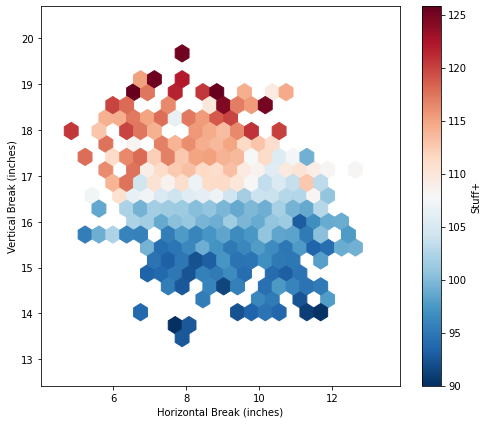

In [26]:
df_p = df_scored[df_scored['PlayerName'] == 'Jacob deGrom']
df_p = df_p[df_p.pitch_type == 'FF']

stuff_movement_heatmap(df_p, stuff_col="Stuff+_global")